In [85]:
using LinearAlgebra
using Statistics
using Roots          # for root-finding (p*, p_oj cutoffs)
using NLsolve        # optional: for Anderson acceleration / system solve
using Interpolations # for interpolating surplus on p-grid
using QuadGK         # adaptive quadrature (cross-checks)
using Plots          # visualisation
using Printf

In [86]:
# ============================================================
# Parameters
# ============================================================

"""
    Params

All primitives for the Pissarides Ch.4 model:
on-the-job search with endogenous separation and match-quality shocks.

Match quality p ~ Gamma_z = Beta(alpha, 1), i.e. CDF = p^alpha, on [0,1].
"""
Base.@kwdef struct Params
    # Preferences / flow values
    r::Float64      = 0.05      # discount rate
    b::Float64      = 0.4       # flow value of unemployment
    sigma::Float64  = 0.02      # flow cost of on-the-job search
    beta::Float64   = 0.5       # worker Nash bargaining weight

    # Productivity
    y::Float64      = 1.0       # aggregate productivity (flow output = y*p)

    # Match quality distribution: Gamma(p) = p^alpha, gamma(p) = alpha * p^(alpha-1)
    alpha::Float64  = 2.0       # shape parameter

    # Shock rates
    lambda::Float64 = 0.10      # Poisson rate of quality redraw shocks
    xi::Float64     = 0.03      # exogenous separation rate
    nu::Float64     = 0.00      # demographic exit rate (set 0 for pure Ch.4)

    # Vacancy / matching
    k::Float64      = 0.30      # flow cost of posting a vacancy
    mu::Float64     = 1.0       # matching function scale
    eta::Float64    = 0.5       # matching function elasticity (Cobb-Douglas)

    # Numerical grid
    Np::Int         = 200       # number of p grid points
    p_min::Float64  = 1e-4      # lower bound of p grid (avoid 0)
    p_max::Float64  = 1.0       # upper bound of p grid

    # Solver tolerances
    tol_inner::Float64  = 1e-10
    tol_outer::Float64  = 1e-8
    max_iter_inner::Int = 2_000
    max_iter_outer::Int = 500

    # Anderson acceleration history length (for theta update)
    anderson_m::Int = 5

    # Dampening on outer updates
    dampen::Float64 = 0.5
    dampen_pstar::Float64 = 0.30 
end


# ============================================================
# Grid
# ============================================================

"""
    Grid

Precomputed p-grid and match-quality distribution objects.
"""
struct Grid
    p::Vector{Float64}          # p grid points  [Np]
    dp::Vector{Float64}         # grid spacing   [Np]  (for simple quadrature)
    Γ::Vector{Float64}          # CDF: Γ(p) = p^alpha
    γ::Vector{Float64}          # PDF: γ(p) = alpha * p^(alpha-1)
end

function Grid(par::Params)
    p  = collect(range(par.p_min, par.p_max, length = par.Np))
    dp = diff(p); push!(dp, dp[end])         # right-extend for uniform trapezoid
    Γ  = p .^ par.alpha
    γ  = par.alpha .* p .^ (par.alpha - 1)
    return Grid(p, dp, Γ, γ)
end


# ============================================================
# Solution container
# ============================================================

"""
    Solution

Stores the equilibrium objects after solving the Ch.4 model.
"""
mutable struct Solution
    # Scalars
    theta::Float64          # market tightness θ
    p_star::Float64         # separation cutoff p*  (S(p*) = 0)
    p_oj::Float64           # OJS cutoff p_oj       (S^1 = S^0)
    U::Float64              # unemployment value
    Iall::Float64     # integral of surplus over OJS region: Iall = ∫_{p*}^1 S·γ dp

    # p-grid functions  [Np]
    S0::Vector{Float64}     # surplus, no OJS
    S1::Vector{Float64}     # surplus, with OJS
    S::Vector{Float64}      # surplus = max(S0, S1)
    s_star::Vector{Bool}    # OJS policy: true if worker searches at p

    J0::Vector{Float64}     # firm value, no OJS
    J1::Vector{Float64}     # firm value, with OJS
    J::Vector{Float64}      # firm value under optimal OJS policy

    E0::Vector{Float64}     # worker employed value, no OJS
    E1::Vector{Float64}     # worker employed value, with OJS
    w0::Vector{Float64}     # wage, no OJS
    w1::Vector{Float64}     # wage, with OJS

    # Stationary distributions  [Np]
    u::Float64              # unemployment mass (scalar: no x heterogeneity)
    e::Vector{Float64}      # employment density over p
end

function Solution(par::Params, grid::Grid)
    Np = par.Np
    return Solution(
        1.0, 0.1, 0.5, 0.0, 0.0,    # theta, p_star, p_oj, U, Iall
        zeros(Np), zeros(Np), zeros(Np), falses(Np),
        zeros(Np), zeros(Np), zeros(Np),
        zeros(Np), zeros(Np), zeros(Np), zeros(Np),
        0.5, zeros(Np)
    )
end

Solution

In [87]:
# ============================================================
# Matching technology
# ============================================================

"""Contact rate per vacancy: q(θ) = μ θ^{-η}"""
q(theta::Float64, par::Params) = par.mu * theta^(-par.eta)

"""Contact rate per job seeker: κ(θ) = θ q(θ) = μ θ^{1-η}"""
kappa(theta::Float64, par::Params) = theta * q(theta, par)

"""Invert q(θ) = target  →  θ = (μ/target)^{1/η}"""
theta_from_q(q_target::Float64, par::Params) = (par.mu / q_target)^(1.0 / par.eta)


# ============================================================
# Distribution helpers  (Γ(p) = p^α, γ(p) = α p^{α-1})
# ============================================================

Γ_cdf(p::Float64, par::Params) = p^par.alpha
γ_pdf(p::Float64, par::Params) = par.alpha * p^(par.alpha - 1.0)

"""
    integrate_above(f, grid, i_lb)

Trapezoidal integral  ∫_{p[i_lb]}^{1}  f(p) dp  over the grid.
"""
function integrate_above(f::Vector{Float64}, grid::Grid, i_lb::Int)
    s = 0.0
    Np = length(grid.p)
    for i in i_lb:(Np - 1)
        s += 0.5 * (f[i] + f[i+1]) * (grid.p[i+1] - grid.p[i])
    end
    return s
end

"""
    integrate_between(f, grid, i_lb, i_ub)

Trapezoidal integral  ∫_{p[i_lb]}^{p[i_ub]}  f(p) dp  over the grid.
"""
function integrate_between(f::Vector{Float64}, grid::Grid, i_lb::Int, i_ub::Int)
    i_lb >= i_ub && return 0.0
    s = 0.0
    for i in i_lb:(i_ub - 1)
        s += 0.5 * (f[i] + f[i+1]) * (grid.p[i+1] - grid.p[i])
    end
    return s
end

"""
    integral_S_gamma(S, grid, par, i_lb)

Compute  ∫_{p*}^{1} S(p) γ(p) dp  where the lower limit is grid point i_lb.
"""
function integral_S_gamma(S::Vector{Float64}, grid::Grid, i_lb::Int)
    f = S .* grid.γ          # element-wise: S(p)*γ(p)
    return integrate_above(f, grid, i_lb)
end

"""
    integral_S_gamma_below(S, grid, i_lb, i_ub)

Compute  ∫_{p*}^{p_ub} S(p) γ(p) dp  (used in the OJS ladder term).
"""
function integral_S_gamma_below(S::Vector{Float64}, grid::Grid, i_lb::Int, i_ub::Int)
    f = S .* grid.γ
    return integrate_between(f, grid, i_lb, i_ub)
end


# ============================================================
# Grid index helpers
# ============================================================

"""Return the index of the grid point nearest to (and ≥) p_val."""
function find_lb_index(p_val::Float64, grid::Grid)
    idx = searchsortedfirst(grid.p, p_val)
    return clamp(idx, 1, length(grid.p))
end


# ============================================================
# Anderson acceleration  (scalar or vector)
# ============================================================

"""
    AndersonAcc{T}

Minimal Anderson acceleration buffer for iterating x ← G(x).
Call `anderson_step!(acc, x_new)` to get the accelerated update.
"""
mutable struct AndersonAcc
    m::Int                          # history length
    X::Vector{Vector{Float64}}      # iterate history
    R::Vector{Vector{Float64}}      # residual history
end

AndersonAcc(m::Int) = AndersonAcc(m, Vector{Float64}[], Vector{Float64}[])

function anderson_step!(acc::AndersonAcc, x_old::Vector{Float64}, Gx::Vector{Float64})
    res = Gx .- x_old
    push!(acc.X, copy(x_old))
    push!(acc.R, copy(res))
    if length(acc.X) > acc.m
        popfirst!(acc.X); popfirst!(acc.R)
    end
    mk = length(acc.R)
    if mk == 1
        return Gx   # plain fixed-point step on first iteration
    end
    # Build residual matrix and solve least squares
    ΔR = hcat([acc.R[i+1] .- acc.R[i] for i in 1:(mk-1)]...)
    γ_aa = ΔR \ (-acc.R[end])         # mk-1 coefficients
    # Blend iterates
    x_acc = copy(Gx)
    for i in 1:(mk-1)
        x_acc .+= γ_aa[i] .* ((acc.X[i+1] .+ acc.R[i+1]) .- Gx)
    end
    return x_acc
end

# Scalar convenience wrapper
function anderson_step_scalar!(acc::AndersonAcc, x_old::Float64, Gx::Float64)
    v = anderson_step!(acc, [x_old], [Gx])
    return v[1]
end


# ============================================================
# Printing / diagnostics
# ============================================================

function print_outer(n::Int, theta::Float64, p_star::Float64, p_oj::Float64, err::Float64)
    @printf("  [outer %3d]  θ = %.5f   p* = %.4f   p_oj = %.4f   err = %.2e\n",
            n, theta, p_star, p_oj, err)
end

print_outer (generic function with 1 method)

In [88]:
# ============================================================
# Cell 4 — Direct Surplus Solver (no inner iteration)
# ============================================================
#
# Key identity: both surplus equations are LINEAR in Iall = ∫_{p*}^1 S·γ dp
#
#   OJS region  [p*, p_oj]:  S = S¹(p) = f(p) + g(p)·Iall
#                              built via a forward (Volterra) sweep
#   No-OJS      [p_oj,  1]:  S = S⁰(p) = h(p) + c·Iall        (pointwise)
#
#   Collecting:  Iall = (I_f + I_h) + (I_g + I_c)·Iall
#   =>           Iall = (I_f + I_h) / (1 - I_g - I_c)     ← one scalar solve
#
# This is exact; no iteration, no risk of non-convergence.

function solve_surplus!(sol::Solution, par::Params, grid::Grid;
                        verbose::Bool = false)
    Np = par.Np
    κ  = kappa(sol.theta, par)
    D0 = par.r + par.nu + par.xi + par.lambda   # S⁰ denominator

    i_lb = find_lb_index(sol.p_star, grid)
    i_oj = clamp(find_lb_index(sol.p_oj, grid), i_lb, Np)

    # ── Step 1: Forward Volterra sweep in OJS region [i_lb, i_oj] ──
    # S¹(p_i)  = f[i] + g[i]·Iall
    # Ib(p_i)  = F[i] + G[i]·Iall   where  Ib(p) ≡ ∫_{p*}^p S·γ dp'

    f = zeros(Np);  g = zeros(Np)
    F = zeros(Np);  G = zeros(Np)

    for i in i_lb:i_oj
        D1   = D0 + κ*(1.0 - grid.Γ[i])
        Fp   = i > i_lb ? F[i-1] : 0.0
        Gp   = i > i_lb ? G[i-1] : 0.0
        fp   = i > i_lb ? f[i-1] : 0.0
        gp   = i > i_lb ? g[i-1] : 0.0

        f[i] = (par.y*grid.p[i] - par.b - par.sigma - par.beta*κ*Fp) / D1
        g[i] = (par.lambda - par.beta*κ*Gp) / D1

        if i > i_lb
            dp   = grid.p[i] - grid.p[i-1]
            F[i] = Fp + 0.5*(fp*grid.γ[i-1] + f[i]*grid.γ[i])*dp
            G[i] = Gp + 0.5*(gp*grid.γ[i-1] + g[i]*grid.γ[i])*dp
        end
    end

    # ── Step 2: Collect Iall contributions ────────────────────────
    # From OJS region: ∫_{p*}^{p_oj} (f + g·Iall)·γ dp
    I_f = 0.0;  I_g = 0.0
    for i in i_lb:(i_oj - 1)
        dp   = grid.p[i+1] - grid.p[i]
        I_f += 0.5*(f[i]*grid.γ[i] + f[i+1]*grid.γ[i+1])*dp
        I_g += 0.5*(g[i]*grid.γ[i] + g[i+1]*grid.γ[i+1])*dp
    end

    # From no-OJS region: S⁰ = (yp-b)/D0 + (λ-βκ)/D0·Iall
    I_h = 0.0
    for i in i_oj:(Np - 1)
        dp   = grid.p[i+1] - grid.p[i]
        hi   = (par.y*grid.p[i]   - par.b) / D0
        hi1  = (par.y*grid.p[i+1] - par.b) / D0
        I_h += 0.5*(hi*grid.γ[i] + hi1*grid.γ[i+1])*dp
    end
    # Iall coefficient from no-OJS: (λ-βκ)/D0 · ∫_{p_oj}^1 γ dp
    #                              = (λ-βκ)/D0 · (1 - Γ(p_oj))
    I_c = (par.lambda - par.beta*κ) / D0 * (1.0 - grid.Γ[i_oj])

    # ── Step 3: One-shot solve for Iall ───────────────────────────
    denom = 1.0 - I_g - I_c
    # denom > 1 when κ is large (βκ dominates λ), so always well-posed
    Iall = abs(denom) > 1e-14 ? max((I_f + I_h) / denom, 0.0) : 0.0

    verbose && @printf("    [surplus]  κ=%.4f  Iall=%.6f  denom=%.4f  i_lb=%d  i_oj=%d\n",
                       κ, Iall, denom, i_lb, i_oj)

    # ── Step 4: Unemployment value ────────────────────────────────
    # (r+ν)·U = b + β·κ·Iall
    sol.U = (par.b + par.beta*κ*Iall) / max(par.r + par.nu, 1e-12)
    sol.Iall = Iall

    # ── Step 5: Populate grid arrays ─────────────────────────────
    # Running Ib for the wage formula w¹(p) = ... + β(1-β)κ·Ib(p)
    Ib_run = 0.0

    for i in 1:Np
        if i < i_lb
            sol.S0[i] = sol.S1[i] = sol.S[i] = 0.0
            sol.J0[i] = sol.J1[i] = sol.J[i] = 0.0
            sol.E0[i] = sol.E1[i] = sol.U
            sol.w0[i] = sol.w1[i] = 0.0
            sol.s_star[i] = false
            continue
        end

        # S⁰ is defined everywhere above p*
        s0 = max((par.y*grid.p[i] - par.b +
                  (par.lambda - par.beta*κ)*Iall) / D0, 0.0)

        if i <= i_oj
            # OJS region: S¹ from forward sweep
            s1 = max(f[i] + g[i]*Iall, 0.0)
            sol.S0[i]     = s0
            sol.S1[i]     = s1
            sol.S[i]      = max(s0, s1)
            sol.s_star[i] = s1 >= s0
        else
            # No-OJS region: S = S⁰; set S1=0 so diff<0 for update_cutoffs!
            sol.S0[i]     = s0
            sol.S1[i]     = 0.0
            sol.S[i]      = s0
            sol.s_star[i] = false
        end

        sol.J0[i] = (1.0 - par.beta)*sol.S0[i]
        sol.J1[i] = (1.0 - par.beta)*sol.S1[i]
        sol.J[i]  = (1.0 - par.beta)*sol.S[i]
        sol.E0[i] = sol.U + par.beta*sol.S0[i]
        sol.E1[i] = sol.U + par.beta*sol.S1[i]

        # Update running Ib (trapezoidal)
        if i > i_lb
            dp      = grid.p[i] - grid.p[i-1]
            Ib_run += 0.5*(sol.S[i-1]*grid.γ[i-1] + sol.S[i]*grid.γ[i])*dp
        end

        common    = (1.0 - par.beta)*par.b + par.beta*par.y*grid.p[i]
        sol.w0[i] = common + par.beta*(1.0 - par.beta)*κ*Iall
        sol.w1[i] = common + (1.0 - par.beta)*par.sigma +
                    par.beta*(1.0 - par.beta)*κ*Ib_run
    end

    return nothing
end

solve_surplus! (generic function with 1 method)

In [89]:
# ============================================================
# Cell 5 — Outer Helpers: Cutoffs | Distributions | Tightness
# ============================================================

# ============================================================
# Cell 5a — Update cutoffs analytically
# ============================================================
#
# p* is the zero of the ACTIVE surplus at the separation margin.
#
# Case A (normal): p* lies in the OJS region (p* < p_oj).
#   S¹(p*) = 0 with Ib(p*) = 0  →  y·p* - b - σ + λ·Iall = 0
#   p* = (b + σ - λ·Iall) / y
#
# Case B (rare):   p* ≥ p_oj, separation from no-OJS region.
#   S⁰(p*) = 0  →  y·p* - b + (λ - β·κ)·Iall = 0
#   p* = (b - (λ - β·κ)·Iall) / y
#
# We try Case A first; fall back to Case B if the result ≥ p_oj.

function update_cutoffs!(sol::Solution, par::Params, grid::Grid)
    Np   = par.Np
    κ    = kappa(sol.theta, par)
    Iall = sol.Iall      # set by solve_surplus!

    # ── p*: analytical zero of active surplus ─────────────────────
    # Case A: p* in OJS region
    p_star_A = (par.b + par.sigma - par.lambda * Iall) / par.y

    # Case B: p* in no-OJS region
    p_star_B = (par.b - (par.lambda - par.beta * κ) * Iall) / par.y

    # Choose: use A if it gives an interior p* below current p_oj
    if p_star_A < sol.p_oj && p_star_A > grid.p[1]
        p_star_new = p_star_A
    else
        p_star_new = p_star_B
    end

    sol.p_star = clamp(p_star_new, grid.p[1], 0.98)

    # ── p_oj: scan S¹ - S⁰ for sign change ────────────────────────
    # Evaluate S⁰ analytically everywhere using Iall,
    # compare against stored S¹ (valid in [p*, p_oj] from Volterra sweep).
    # For i beyond old i_oj, S¹ was set to 0, so diff = -S⁰ < 0 there.
    # We want the FIRST crossing from positive to negative.
    i_lb = find_lb_index(sol.p_star, grid)
    i_oj = Np    # default: OJS everywhere

    @inbounds for i in i_lb:Np
        s0_i = max((par.y*grid.p[i] - par.b +
                    (par.lambda - par.beta*κ)*Iall) /
                   (par.r + par.nu + par.xi + par.lambda), 0.0)
        # sol.S1[i] is valid in OJS region; 0 outside (set in solve_surplus!)
        if sol.S1[i] < s0_i
            i_oj = i
            break
        end
    end

    if i_lb < i_oj <= Np
        # Linear interpolation between i_oj-1 and i_oj
        s0_lo = max((par.y*grid.p[i_oj-1] - par.b +
                     (par.lambda - par.beta*κ)*Iall) /
                    (par.r + par.nu + par.xi + par.lambda), 0.0)
        s0_hi = max((par.y*grid.p[i_oj] - par.b +
                     (par.lambda - par.beta*κ)*Iall) /
                    (par.r + par.nu + par.xi + par.lambda), 0.0)
        d_lo  = sol.S1[i_oj-1] - s0_lo
        d_hi  = sol.S1[i_oj]   - s0_hi
        Δ     = d_hi - d_lo
        sol.p_oj = abs(Δ) > 1e-14 ?
            grid.p[i_oj-1] - d_lo/Δ*(grid.p[i_oj]-grid.p[i_oj-1]) :
            grid.p[i_oj]
    else
        sol.p_oj = grid.p[clamp(i_oj, 1, Np)]
    end

    sol.p_oj = clamp(sol.p_oj, sol.p_star + 1e-4, grid.p[end])
    return nothing
end

"""
After update_cutoffs! moves p_oj, call this to re-stamp s_star
consistently with the new cutoffs, without rerunning the Volterra sweep.
"""
function refresh_s_star!(sol::Solution, par::Params, grid::Grid)
    i_lb = find_lb_index(sol.p_star, grid)
    i_oj = find_lb_index(sol.p_oj,   grid)
    for i in 1:par.Np
        if i < i_lb
            sol.s_star[i] = false
        elseif i <= i_oj
            sol.s_star[i] = true
        else
            sol.s_star[i] = false
        end
    end
    return nothing
end

# ─────────────────────────────────────────────────────────────
# 5b. Stationary distributions u and e(p)
# ─────────────────────────────────────────────────────────────

"""
    solve_distributions!(sol, par, grid)

Compute stationary unemployment mass `u` and employment density `e(p)`
(normalised so that u + ∫e dp = 1).

Unemployment scalar balance (exact when ν may be zero):
  (ν + κ(1-Γ(p*)) + ξ + λΓ(p*))·u  =  ν + (ξ + λΓ(p*))

Employment density: forward sweep (lower-triangular in p):
  (ν+ξ+λ + s*(p)·κ·(1-Γ(p)))·e(p)
      = κ·γ(p)·u  +  λ·γ(p)·e_tot  +  κ·γ(p)·∫_{p*}^p s*(p')e(p')dp'
"""
function solve_distributions!(sol::Solution, par::Params, grid::Grid)
    Np   = par.Np
    κ    = kappa(sol.theta, par)
    i_lb = find_lb_index(sol.p_star, grid)
    Γ_lb = grid.Γ[i_lb]

    # ── Aggregate unemployment from scalar flow balance ──────
    accept_u   = κ * (1.0 - Γ_lb)           # job-finding rate for u
    sep_hazard = par.xi + par.lambda * Γ_lb  # separation rate from employment
    sol.u      = (par.nu + sep_hazard) / (par.nu + accept_u + sep_hazard)
    e_tot      = 1.0 - sol.u

    # ── Forward sweep for e(p) ───────────────────────────────
    # Strictly lower-triangular: when computing e[i], cum_search
    # holds ∫_{p*}^{p_{i-1}} s*·e dp  (updated AFTER e[i] is set).
    e          = zeros(Np)
    cum_search = 0.0

    @inbounds for i in i_lb:Np
        s_i     = sol.s_star[i] ? 1.0 : 0.0
        quit_hz = s_i * κ * (1.0 - grid.Γ[i])
        lhs     = par.nu + par.xi + par.lambda + quit_hz
        rhs     = κ * grid.γ[i] * sol.u +
                  par.lambda * grid.γ[i] * e_tot +
                  κ * grid.γ[i] * cum_search
        e[i]    = rhs / lhs

        # Trapezoid update (e[i] now known → no circular dependency)
        if i > i_lb
            s_prev      = sol.s_star[i-1] ? 1.0 : 0.0
            cum_search += 0.5 * (s_prev * e[i-1] + s_i * e[i]) *
                          (grid.p[i] - grid.p[i-1])
        end
    end

    # Normalise so ∫ e dp = e_tot
    e_int = integrate_above(e, grid, i_lb)
    e_int > 1e-12 && (e .*= e_tot / e_int)
    sol.e .= e

    return nothing
end


# ─────────────────────────────────────────────────────────────
# 5c. Free-entry implied tightness
# ─────────────────────────────────────────────────────────────

"""
    update_theta(sol, par, grid) -> Float64

Compute the market tightness θ implied by free entry q(θ)·J̄ = k,
where J̄ is the expected firm value per vacancy contact (Ch.4 form):

  J̄ = (1/Ũ)·[ u·∫_{p*}^1 J·γ dp̃
             + ∫_{p*}^1 s*(p)·e(p)·∫_p^1 J·γ dp̃ · dp ]

  Ũ = u + ∫_{p*}^1 s*(p)·e(p) dp   (unemployed + employed searchers)
"""
function update_theta(sol::Solution, par::Params, grid::Grid)
    Np   = par.Np
    i_lb = find_lb_index(sol.p_star, grid)

    # ── Total searchers Ũ ────────────────────────────────────
    s_e     = [sol.s_star[i] ? sol.e[i] : 0.0 for i in 1:Np]
    U_tilde = sol.u + integrate_above(s_e, grid, i_lb)
    U_tilde = max(U_tilde, 1e-12)

    # ── J(p)·γ(p) and its cumulative from p* ─────────────────
    Jγ      = sol.J .* grid.γ
    Jγ_all  = integrate_above(Jγ, grid, i_lb)

    cum_Jγ = zeros(Np)
    for i in (i_lb + 1):Np
        cum_Jγ[i] = cum_Jγ[i-1] +
                    0.5*(Jγ[i-1]+Jγ[i])*(grid.p[i]-grid.p[i-1])
    end
    Jγ_above = Jγ_all .- cum_Jγ

    # ── Employed-searcher contribution ───────────────────────
    emp_int = [s_e[i] * max(Jγ_above[i], 0.0) for i in 1:Np]
    J_emp   = integrate_above(emp_int, grid, i_lb)

    J_bar = (sol.u * Jγ_all + J_emp) / U_tilde

    # Guard: if J_bar ≤ 0 the market shouldn't exist; return
    # a high θ to drive down firm value in the next iteration
    if !isfinite(J_bar) || J_bar <= 1e-12
        return 10.0
    end

    q_target  = par.k / J_bar
    # Guard: q must be in (0, μ] so that θ = (μ/q)^(1/η) is finite
    q_target  = clamp(q_target, 1e-6, par.mu * 0.9999)
    theta_new = theta_from_q(q_target, par)

    return clamp(theta_new, 1e-4, 1e4)
end

update_theta

In [90]:
# ============================================================
# Cell 6 — Outer Loop
# ============================================================

function solve_outer!(sol::Solution, par::Params, grid::Grid;
                      verbose::Bool = true)

    acc = AndersonAcc(par.anderson_m)

    # Keep running exponential-smoothed copies of the cutoffs
    p_star_smooth = sol.p_star
    p_oj_smooth   = sol.p_oj

    err_prev = Inf

    for n in 1:par.max_iter_outer

        θ_prv      = sol.theta
        p_star_prv = p_star_smooth
        p_oj_prv   = p_oj_smooth

        # ── 1. Inner surplus iteration ───────────────────────
        solve_surplus!(sol, par, grid)

        # ── 2. Raw cutoff update ─────────────────────────────
        update_cutoffs!(sol, par, grid)

        # ── 2b. Dampen cutoff updates ────────────────────────
        refresh_s_star!(sol, par, grid)

        # ── 3. Stationary distributions ─────────────────────
        solve_distributions!(sol, par, grid)

        # ── 4. Free-entry implied θ ──────────────────────────
        θ_new = update_theta(sol, par, grid)
        θ_new = clamp(θ_new, 1e-4, 1e4)

        # ── 5. Anderson acceleration + dampening on θ ────────
        θ_acc = anderson_step_scalar!(acc, sol.theta, θ_new)
        θ_acc = clamp(θ_acc, 1e-4, 1e4)
        θ_upd = (1.0 - par.dampen) * sol.theta + par.dampen * θ_acc
        θ_upd = clamp(θ_upd, 1e-4, 1e4)

        # ── 6. Convergence ───────────────────────────────────
        err = max(abs(θ_upd         - θ_prv),
                  abs(sol.p_star - p_star_prv),
                  abs(sol.p_oj   - p_oj_prv))

        sol.theta = θ_upd

        verbose && (n % 25 == 1 || err < par.tol_outer) &&
            print_outer(n, sol.theta, sol.p_star, sol.p_oj, err)

        if err < par.tol_outer
            verbose && @printf("  ✓ Converged at outer iter %d\n", n)
            break
        end

        n == par.max_iter_outer &&
            verbose && @printf("  ✗ Did not converge — final err = %.2e\n", err)
    end

    # Final consistency pass
    solve_surplus!(sol, par, grid)
    update_cutoffs!(sol, par, grid)
    solve_distributions!(sol, par, grid)

    return nothing
end


function initialise_model(par::Params)
    grid = Grid(par)
    sol  = Solution(par, grid)

    sol.theta  = 1.0
    sol.p_star = clamp(par.b / par.y, grid.p[1] + 1e-3, 0.90)
    sol.p_oj   = clamp((sol.p_star + 1.0) / 2.0, sol.p_star + 1e-3, 0.99)
    sol.u      = 0.3

    top_S = (par.y - par.b) / (par.r + par.xi + par.lambda)
    i_lb  = find_lb_index(sol.p_star, grid)
    span  = max(1.0 - sol.p_star, 1e-8)
    for i in i_lb:par.Np
        frac      = (grid.p[i] - sol.p_star) / span
        sol.S[i]  = top_S * frac
        sol.S0[i] = sol.S[i]
        sol.S1[i] = sol.S[i]
        sol.J[i]  = (1.0 - par.beta) * sol.S[i]
    end

    return sol, grid
end


function solve_model(par::Params; verbose::Bool = true)

    sol, grid = initialise_model(par)

    verbose && println("\n══ Pissarides Ch.4 model ══════════════════════════════")
    verbose && @printf("   Np=%d  r=%.3f  b=%.3f  σ=%.3f  β=%.2f\n",
                       par.Np, par.r, par.b, par.sigma, par.beta)
    verbose && @printf("   α=%.2f  λ=%.3f  ξ=%.3f  k=%.3f  μ=%.2f  η=%.2f\n\n",
                       par.alpha, par.lambda, par.xi, par.k, par.mu, par.eta)

    solve_outer!(sol, par, grid; verbose = verbose)

    if verbose
        κ = kappa(sol.theta, par)
        println("\n── Equilibrium ──────────────────────────────────────────")
        @printf("  θ  (tightness)      = %8.5f\n", sol.theta)
        @printf("  κ  (contact rate)   = %8.5f\n", κ)
        @printf("  p* (separation)     = %8.5f\n", sol.p_star)
        @printf("  p_oj (OJS cutoff)   = %8.5f\n", sol.p_oj)
        @printf("  U  (unemp. value)   = %8.5f\n", sol.U)
        @printf("  u  (unemp. mass)    = %8.5f\n", sol.u)
        @printf("  e_tot (emp. mass)   = %8.5f\n", 1.0 - sol.u)
        i_lb = find_lb_index(sol.p_star, grid)
        pct_oj = 100 * integrate_above(
                     [sol.s_star[i] ? sol.e[i] : 0.0 for i in 1:par.Np],
                     grid, i_lb) / max(1.0 - sol.u, 1e-12)
        @printf("  %% employed searching = %6.2f %%\n", pct_oj)
        println("─────────────────────────────────────────────────────────\n")
    end

    return sol, grid
end

solve_model (generic function with 1 method)


══ Pissarides Ch.4 model ══════════════════════════════
   Np=300  r=0.050  b=0.050  σ=0.020  β=0.30
   α=3.00  λ=0.190  ξ=0.020  k=0.550  μ=0.60  η=0.50

  [outer   1]  θ = 2.42801   p* = 0.0226   p_oj = 0.0235   err = 1.43e+00
  [outer  26]  θ = 2.37796   p* = 0.2269   p_oj = 0.2993   err = 2.26e-01
  [outer  51]  θ = 2.37778   p* = 0.2271   p_oj = 0.3814   err = 1.77e-01
  [outer  76]  θ = 2.37736   p* = 0.2271   p_oj = 0.3865   err = 1.77e-01
  [outer 101]  θ = 2.37736   p* = 0.2271   p_oj = 0.3865   err = 1.77e-01
  [outer 126]  θ = 2.37736   p* = 0.2271   p_oj = 0.3865   err = 1.77e-01
  [outer 151]  θ = 2.37736   p* = 0.2271   p_oj = 0.3865   err = 1.77e-01
  [outer 176]  θ = 2.37736   p* = 0.2271   p_oj = 0.3865   err = 1.77e-01
  [outer 201]  θ = 2.37736   p* = 0.2271   p_oj = 0.3865   err = 1.77e-01
  [outer 226]  θ = 2.37736   p* = 0.2271   p_oj = 0.3865   err = 1.77e-01
  [outer 251]  θ = 2.37736   p* = 0.2271   p_oj = 0.3865   err = 1.77e-01
  [outer 276]  θ = 2.37736   p

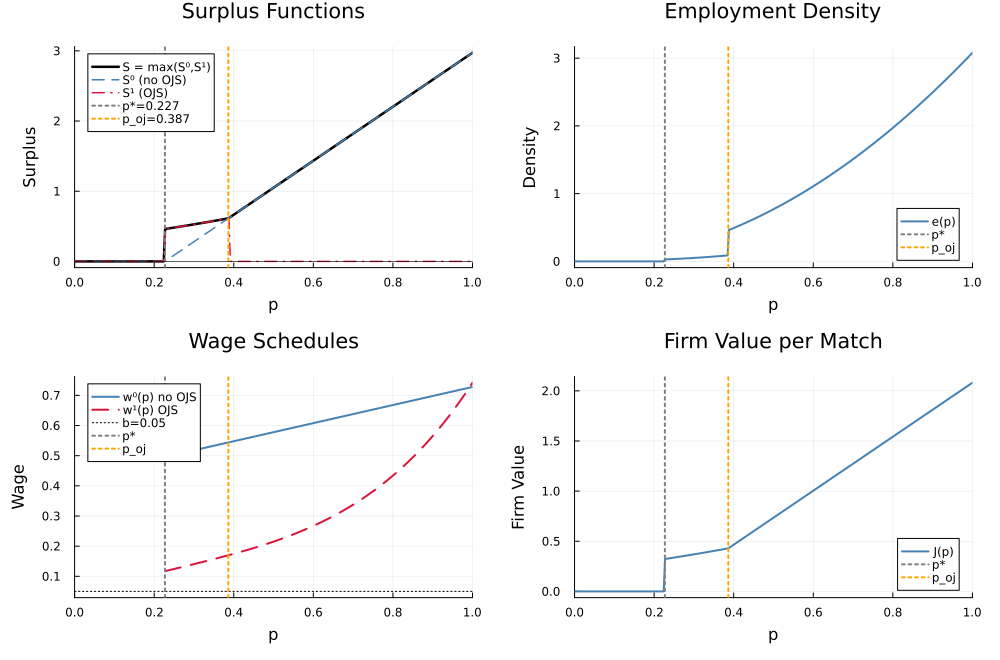

In [91]:
# ============================================================
# Cell 7 — parameters, solve, plot
# ============================================================
#
# Why k=0.40 and not 0.20:
#   At θ~1, E[J_bar] ≈ (1-β)·E[S] ≈ 0.5 · ∫(p-p*)/(r+ξ+λ)·γ dp ≈ 0.45
#   Free entry: k = q(θ)·J_bar ≈ 1.0·0.45 = 0.45
#   => k must be close to 0.4–0.5 for an interior θ~1–2.
#   k=0.20 implies the firm wants θ~25, which is why it hit the upper bound.

par = Params(
    r      = 0.05,
    b      = 0.05,   # ← primary lever: raise from 0.05 → 0.40
                     #   higher outside option makes low-p matches unprofitable
    sigma  = 0.02,
    beta   = 0.30,
    y      = 1.00,      # ← primary lever: raise from 0.50 → 1.00
                       #   higher output per match → more surplus to share
                       #   → p* rises and more OJS
    alpha  = 3.00,      # ← shape of p distribution: higher α → more mass near p=1 → higher p* and more OJS
                      #   (α=1 is uniform; α>1 is concave with more mass near 1)
    lambda = 0.19,   # ← secondary lever: lower from 0.40 → 0.15
                     #   fewer redraws → less option value from staying in bad match
                     #   → option value term (λ-βκ)Iall shrinks → p* rises
    xi     = 0.02,   
    nu     = 0.00,   
    k      = 0.55,   # ← tertiary lever: raise from 0.40 → 0.55
                     #   higher posting cost → lower θ → lower κ
                     #   → less surplus from contact → p* rises
    mu     = 0.60,
    eta    = 0.50,
    Np     = 300,
    dampen       = 0.40,
    dampen_pstar = 0.30,
)

sol, grid = solve_model(par; verbose = true)

# ── always plot over full [0,1] so narrow OJS window is visible ──
pgrid_full = grid.p     # full grid

p1 = plot(pgrid_full, sol.S,
          label="S = max(S⁰,S¹)", lw=2.5, color=:black,
          xlabel="p", ylabel="Surplus", title="Surplus Functions",
          xlims=(0,1))
plot!(p1, pgrid_full, sol.S0, label="S⁰ (no OJS)",
      lw=1.5, ls=:dash, color=:steelblue)
plot!(p1, pgrid_full, sol.S1, label="S¹ (OJS)",
      lw=1.5, ls=:dashdot, color=:crimson)
vline!(p1, [sol.p_star], ls=:dot, color=:grey,   lw=2, label="p*=$(round(sol.p_star,digits=3))")
vline!(p1, [sol.p_oj],   ls=:dot, color=:orange, lw=2, label="p_oj=$(round(sol.p_oj,digits=3))")
hline!(p1, [0.0], color=:black, lw=0.6, label="")

p2 = plot(pgrid_full, sol.e,
          label="e(p)", lw=2, color=:steelblue,
          xlabel="p", ylabel="Density", title="Employment Density",
          xlims=(0,1))
vline!(p2, [sol.p_star], ls=:dot, color=:grey,   lw=2, label="p*")
vline!(p2, [sol.p_oj],   ls=:dot, color=:orange, lw=2, label="p_oj")

i_lb = find_lb_index(sol.p_star, grid)
p3 = plot(pgrid_full[i_lb:end], sol.w0[i_lb:end],
          label="w⁰(p) no OJS", lw=2, color=:steelblue,
          xlabel="p", ylabel="Wage", title="Wage Schedules",
          xlims=(0,1))
plot!(p3, pgrid_full[i_lb:end], sol.w1[i_lb:end],
      label="w¹(p) OJS", lw=2, ls=:dash, color=:crimson)
hline!(p3, [par.b], label="b=$(par.b)", ls=:dot, color=:black, lw=1)
vline!(p3, [sol.p_star], ls=:dot, color=:grey,   lw=2, label="p*")
vline!(p3, [sol.p_oj],   ls=:dot, color=:orange, lw=2, label="p_oj")

# OJS policy: show as region fill, not just a line
s_int = Float64.(sol.s_star)
p4 = plot(pgrid_full, sol.J,
          label="J(p)", lw=2, color=:steelblue,
          xlabel="p", ylabel="Firm Value",
          title="Firm Value per Match",
          xlims=(0,1))
vline!(p4, [sol.p_star], ls=:dot, color=:grey,   lw=2, label="p*")
vline!(p4, [sol.p_oj],   ls=:dot, color=:orange, lw=2, label="p_oj")  

plot(p1, p2, p3, p4,
     layout=(2,2), size=(1000,660), margin=5Plots.mm)

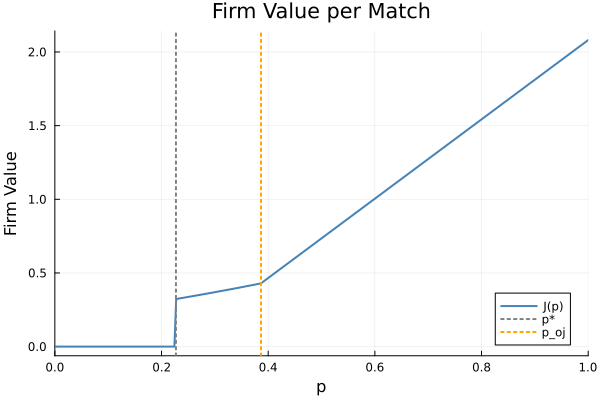

In [92]:
# plot value functions
#firm
p5 = plot(pgrid_full, sol.J,
          label="J(p)", lw=2, color=:steelblue,
          xlabel="p", ylabel="Firm Value",
          title="Firm Value per Match",
          xlims=(0,1))
vline!(p5, [sol.p_star], ls=:dot, color=:grey,   lw=2, label="p*")
vline!(p5, [sol.p_oj],   ls=:dot, color=:orange, lw=2, label="p_oj")      